In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as mticker


In [2]:
path_in = '../data/'
path_output = '../figures/'

In [9]:

ds_gs_cyc = xr.open_dataset(path_in + 'composite_swot_GS2_cyclonic_biharmonic_currents.nc')
ds_agulhas_cyc = xr.open_dataset(path_in + 'composite_swot_AGULHAS_cyclonic_biharmonic_currents.nc')
ds_ccs_cyc = xr.open_dataset(path_in + 'composite_swot_CCS_cyclonic_biharmonic_currents.nc')
ds_acc1_cyc = xr.open_dataset(path_in + 'composite_swot_ACC1_bis_cyclonic_biharmonic_currents.nc')
ds_acc2_cyc = xr.open_dataset(path_in + 'composite_swot_ACC2_cyclonic_biharmonic_currents.nc')
ds_med_cyc = xr.open_dataset(path_in + 'composite_swot_MED_cyclonic_biharmonic_currents.nc')



ds_gs_anticyc = xr.open_dataset(path_in + 'composite_swot_GS2_anticyclonic_biharmonic_currents.nc')
ds_agulhas_anticyc = xr.open_dataset(path_in + 'composite_swot_AGULHAS_anticyclonic_biharmonic_currents.nc')
ds_ccs_anticyc = xr.open_dataset(path_in + 'composite_swot_CCS_anticyclonic_biharmonic_currents.nc')
ds_acc1_anticyc = xr.open_dataset(path_in + 'composite_swot_ACC1_bis_anticyclonic_biharmonic_currents.nc')
ds_acc2_anticyc = xr.open_dataset(path_in + 'composite_swot_ACC2_anticyclonic_biharmonic_currents.nc')
ds_med_anticyc = xr.open_dataset(path_in + 'composite_swot_MED_anticyclonic_biharmonic_currents.nc')



ds_gs_cyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_GS2_cyclonic.nc')
ds_agulhas_cyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_AGULHAS_cyclonic.nc')
ds_ccs_cyc_duacs = xr.open_dataset(path_in+ 'composite_swot_like_CCS_cyclonic_current.nc')
ds_acc1_cyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_ACC1_bis_cyclonic.nc')
ds_acc2_cyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_ACC2_cyclonic.nc')
ds_med_cyc_duacs = xr.open_dataset(path_in + 'composite_swot_like_MED_cyclonic_current.nc')



ds_gs_anticyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_GS2_anticyclonic.nc')
ds_agulhas_anticyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_AGULHAS_anticyclonic.nc')
ds_ccs_anticyc_duacs = xr.open_dataset(path_in + 'composite_swot_like_CCS_anticyclonic_current.nc')
ds_acc1_anticyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_ACC1_bis_anticyclonic.nc')
ds_acc2_anticyc_duacs = xr.open_dataset(path_in + 'composite_DUACS_ACC2_anticyclonic.nc')
ds_med_anticyc_duacs = xr.open_dataset(path_in + 'composite_swot_like_MED_anticyclonic_current.nc')




In [11]:


theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

x_circle_small = np.cos(theta)/2.5
y_circle_small = np.sin(theta)/2.5


arrow_length = 0.8  # Adjust length as needed
x_start = 0
y_start = 0
theta_rot = 0
x_end = x_start + arrow_length * np.cos(theta_rot*(+1))
y_end = y_start + arrow_length * np.sin(theta_rot*(+1))

props1 = dict(boxstyle='round', facecolor='w', alpha=1)
n_quiver = 15


def plot_composite(ax, compo_2D, vmin, vmax, cmap0):
    p1 = ax.pcolormesh(compo_2D.x, compo_2D.y,  compo_2D, vmin = vmin, vmax = vmax, cmap = cmap0)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')
    ax.set_xticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'], rotation = 90)
    ax.set_yticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'])

    
    ax.plot(x_circle_small, y_circle_small, color = 'k', linewidth = 2)
    ax.plot(x_circle_small, y_circle_small, color = 'w', linewidth = .5)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')

    
    # ax.text(0.05, 0.9, letter,
    #      transform = ax.transAxes, bbox = props1, fontsize = 9)
    return p1

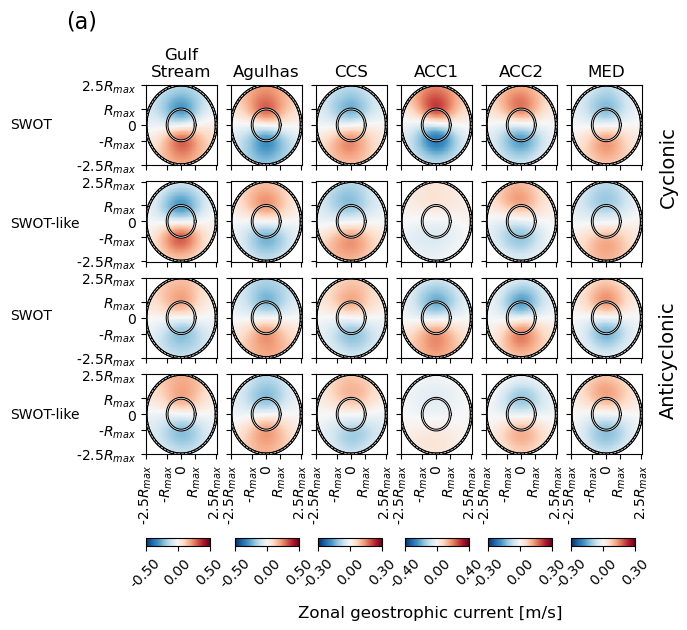

In [14]:
fig, axes = plt.subplots(ncols = 6, nrows = 4, sharex = True, sharey = True)

nb_quiver = 33
ax = axes[0][0]
ax.set_title('Gulf\nStream')
vmin = -.5
vmax = .5
p1 = plot_composite(ax, ds_gs_cyc.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][0]
_ = plot_composite(ax, ds_gs_cyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][0]
_ = plot_composite(ax, ds_gs_anticyc.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[3][0]
_ = plot_composite(ax, ds_gs_anticyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')

cax = fig.add_axes([.125, -.08, .1, 0.015])
cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

cbar.ax.tick_params(rotation=45)

ax = axes[0][1]
vmin = -.5
vmax = .5
ax.set_title('Agulhas')
p1 = plot_composite(ax, ds_agulhas_cyc.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][1]
_ = plot_composite(ax, ds_agulhas_cyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')


ax = axes[2][1]
_ = plot_composite(ax, ds_agulhas_anticyc.composite[0,:,:], vmin, vmax, 'RdBu_r')


ax = axes[3][1]
_ = plot_composite(ax, ds_agulhas_anticyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')


cax = fig.add_axes([.265, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][2]
vmin = -.3
vmax = .3
ax.set_title('CCS')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1= plot_composite(ax, ds_ccs_cyc.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][2]
_ = plot_composite(ax, ds_ccs_cyc_duacs.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][2]
_ = plot_composite(ax, ds_ccs_anticyc.composite[0,:,:], vmin, vmax, 'RdBu_r')

ax = axes[3][2]
_ = plot_composite(ax, ds_ccs_anticyc_duacs.composite[0,:,:], vmin, vmax, 'RdBu_r')

cax = fig.add_axes([.395, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)



ax = axes[0][3]
vmin = -.4
vmax = .4
ax.set_title('ACC1')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_acc1_cyc.composite[0,:,:], vmin, vmax, 'RdBu_r')


ax = axes[1][3]
_ = plot_composite(ax, ds_acc1_cyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][3]
_ = plot_composite(ax,  ds_acc1_anticyc.composite[0,:,:], vmin, vmax, 'RdBu_r')



ax = axes[3][3]
_ = plot_composite(ax,  ds_acc1_anticyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')


cax = fig.add_axes([.53, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][4]
vmin = -.3
vmax = .3
ax.set_title('ACC2')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_acc2_cyc.composite[0,:,:],  vmin, vmax,  'RdBu_r')

ax = axes[1][4]
_ = plot_composite(ax, ds_acc2_cyc_duacs.composite[1,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[2][4]
_ = plot_composite(ax, ds_acc2_anticyc.composite[0,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[3][4]
_ = plot_composite(ax, ds_acc2_anticyc_duacs.composite[1,:,:], vmin, vmax,  'RdBu_r')



cax = fig.add_axes([.66, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])

cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][5]
vmin = -.3
vmax = .3
ax.set_title('MED')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_med_cyc.composite[0,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[1][5]
_ = plot_composite(ax, ds_med_cyc_duacs.composite[0,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[2][5]
_ = plot_composite(ax, ds_med_anticyc.composite[0,:,:],  vmin, vmax,  'RdBu_r')

ax = axes[3][5]
_ = plot_composite(ax, ds_med_anticyc_duacs.composite[0,:,:], vmin, vmax,  'RdBu_r')



cax = fig.add_axes([.79, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# cbar.ax.set_xticklabels(clevs1[::1] rotation=90)
cbar.ax.tick_params(rotation=45)
# cbar.ax.set_title('Current speed [m/s]')
ax.text(-17, -.1, 'SWOT-like')
ax.text(-17, 2.4, 'SWOT')
ax.text(-17, 4.7, 'SWOT-like')
ax.text(-17, 7.2, 'SWOT')
ax.text(1.5, 0, 'Anticyclonic', rotation = 90, fontsize = 14)
ax.text(1.5, 5.3, 'Cyclonic', rotation = 90, fontsize = 14)
ax.text(-8.8, -5.1, 'Zonal geostrophic current [m/s]', fontsize = 12)
fig.text(0, 1, '(a)', fontsize = 16)
plt.savefig(path_output + 'Fig_S4_u.png', dpi = 300, bbox_inches = 'tight')


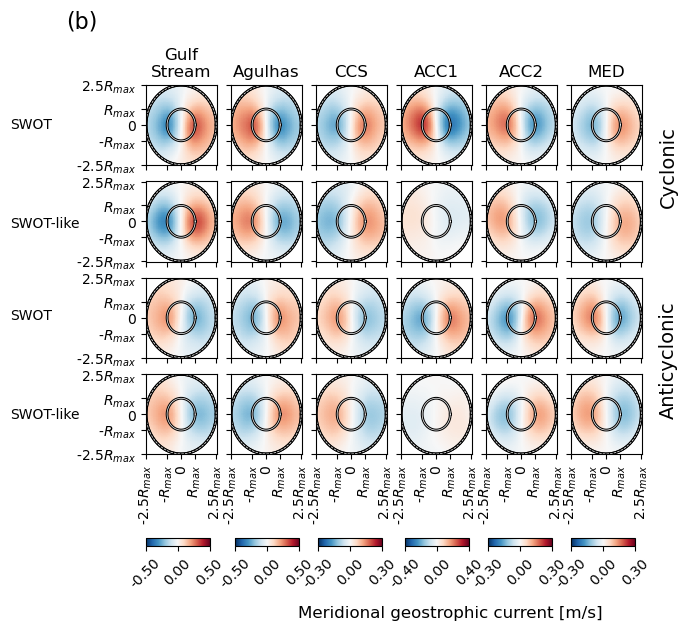

In [15]:
fig, axes = plt.subplots(ncols = 6, nrows = 4, sharex = True, sharey = True)

nb_quiver = 33
ax = axes[0][0]
ax.set_title('Gulf\nStream')
vmin = -.5
vmax = .5
p1 = plot_composite(ax, ds_gs_cyc.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][0]
_ = plot_composite(ax, ds_gs_cyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][0]
_ = plot_composite(ax, ds_gs_anticyc.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[3][0]
_ = plot_composite(ax, ds_gs_anticyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')

cax = fig.add_axes([.125, -.08, .1, 0.015])
cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

cbar.ax.tick_params(rotation=45)

ax = axes[0][1]
vmin = -.5
vmax = .5
ax.set_title('Agulhas')
p1 = plot_composite(ax, ds_agulhas_cyc.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][1]
_ = plot_composite(ax, ds_agulhas_cyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')


ax = axes[2][1]
_ = plot_composite(ax, ds_agulhas_anticyc.composite[1,:,:], vmin, vmax, 'RdBu_r')


ax = axes[3][1]
_ = plot_composite(ax, ds_agulhas_anticyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')


cax = fig.add_axes([.265, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][2]
vmin = -.3
vmax = .3
ax.set_title('CCS')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1= plot_composite(ax, ds_ccs_cyc.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[1][2]
_ = plot_composite(ax, ds_ccs_cyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][2]
_ = plot_composite(ax, ds_ccs_anticyc.composite[1,:,:], vmin, vmax, 'RdBu_r')

ax = axes[3][2]
_ = plot_composite(ax, ds_ccs_anticyc_duacs.composite[1,:,:], vmin, vmax, 'RdBu_r')

cax = fig.add_axes([.395, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)



ax = axes[0][3]
vmin = -.4
vmax = .4
ax.set_title('ACC1')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_acc1_cyc.composite[1,:,:], vmin, vmax, 'RdBu_r')


ax = axes[1][3]
_ = plot_composite(ax, ds_acc1_cyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')

ax = axes[2][3]
_ = plot_composite(ax,  ds_acc1_anticyc.composite[1,:,:], vmin, vmax, 'RdBu_r')



ax = axes[3][3]
_ = plot_composite(ax,  ds_acc1_anticyc_duacs.composite[2,:,:], vmin, vmax, 'RdBu_r')


cax = fig.add_axes([.53, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][4]
vmin = -.3
vmax = .3
ax.set_title('ACC2')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_acc2_cyc.composite[1,:,:],  vmin, vmax,  'RdBu_r')

ax = axes[1][4]
_ = plot_composite(ax, ds_acc2_cyc_duacs.composite[2,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[2][4]
_ = plot_composite(ax, ds_acc2_anticyc.composite[1,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[3][4]
_ = plot_composite(ax, ds_acc2_anticyc_duacs.composite[2,:,:], vmin, vmax,  'RdBu_r')



cax = fig.add_axes([.66, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])

cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][5]
vmin = -.3
vmax = .3
ax.set_title('MED')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, ds_med_cyc.composite[1,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[1][5]
_ = plot_composite(ax, ds_med_cyc_duacs.composite[1,:,:],  vmin, vmax,  'RdBu_r')


ax = axes[2][5]
_ = plot_composite(ax, ds_med_anticyc.composite[1,:,:],  vmin, vmax,  'RdBu_r')

ax = axes[3][5]
_ = plot_composite(ax, ds_med_anticyc_duacs.composite[1,:,:], vmin, vmax,  'RdBu_r')



cax = fig.add_axes([.79, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# cbar.ax.set_xticklabels(clevs1[::1] rotation=90)
cbar.ax.tick_params(rotation=45)
# cbar.ax.set_title('Current speed [m/s]')
ax.text(-17, -.1, 'SWOT-like')
ax.text(-17, 2.4, 'SWOT')
ax.text(-17, 4.7, 'SWOT-like')
ax.text(-17, 7.2, 'SWOT')
ax.text(1.5, 0, 'Anticyclonic', rotation = 90, fontsize = 14)
ax.text(1.5, 5.3, 'Cyclonic', rotation = 90, fontsize = 14)
ax.text(-8.8, -5.1, 'Meridional geostrophic current [m/s]', fontsize = 12)
fig.text(0, 1, '(b)', fontsize = 16)
plt.savefig(path_output + 'Fig_S4_v.png', dpi = 300, bbox_inches = 'tight')
